In [1]:
import os

from IPython.terminal.pt_inputhooks import registered
from IPython.utils import data
from requests.utils import dict_from_cookiejar

print(os.getcwd())

C:\Users\User\PythonProjects\bike_share_system


In [2]:
# 1. Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# . Load hour.csv raw data
df = pd.read_csv('data/raw/hour.csv')

#2. Review 1st 10 rows
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [3]:
# Alter column names for readability
df_clean = df.rename(columns={
    'instant': 'record_id',
    'dteday': 'date',
    'yr': 'year',
    'mnth': 'month',
    'hr': 'hour',
    'weathersit': 'weather',
    'atemp': 'real_feel',
    'hum': 'humidity',
    'windspeed': 'wind_speed',
    'casual': 'casual_rider',
    'registered': 'registered_rider',
    'cnt': 'rental_count',
})

In [4]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   record_id         17379 non-null  int64  
 1   date              17379 non-null  str    
 2   season            17379 non-null  int64  
 3   year              17379 non-null  int64  
 4   month             17379 non-null  int64  
 5   hour              17379 non-null  int64  
 6   holiday           17379 non-null  int64  
 7   weekday           17379 non-null  int64  
 8   workingday        17379 non-null  int64  
 9   weather           17379 non-null  int64  
 10  temp              17379 non-null  float64
 11  real_feel         17379 non-null  float64
 12  humidity          17379 non-null  float64
 13  wind_speed        17379 non-null  float64
 14  casual_rider      17379 non-null  int64  
 15  registered_rider  17379 non-null  int64  
 16  rental_count      17379 non-null  int64  
dtypes: f

In [5]:
# Normalize column names
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)


In [6]:
# Change datatype from int to date
df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean['year'] = df_clean['date'].dt.year
df_clean['month'] = df_clean['date'].dt.month


In [7]:
print(df_clean['hour'].head())

0    0
1    1
2    2
3    3
4    4
Name: hour, dtype: int64


In [8]:
# Five number summary: mean, std dev, min, max, IQR + count
df_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
record_id,17379.0,8690.0,1.0,4345.5,8690.0,13034.5,17379.0,5017.0295
date,17379,2012-01-02 04:08:34.552045,2011-01-01 00:00:00,2011-07-04 00:00:00,2012-01-02 00:00:00,2012-07-02 00:00:00,2012-12-31 00:00:00,NaN
season,17379.0,2.50164,1.0,2.0,3.0,3.0,4.0,1.106918
year,17379.0,2011.502561,2011.0,2011.0,2012.0,2012.0,2012.0,0.500008
month,17379.0,6.537775,1.0,4.0,7.0,10.0,12.0,3.438776
hour,17379.0,11.546752,0.0,6.0,12.0,18.0,23.0,6.914405
holiday,17379.0,0.02877,0.0,0.0,0.0,0.0,1.0,0.167165
weekday,17379.0,3.003683,0.0,1.0,3.0,5.0,6.0,2.005771
workingday,17379.0,0.682721,0.0,0.0,1.0,1.0,1.0,0.465431
weather,17379.0,1.425283,1.0,1.0,1.0,2.0,4.0,0.639357


In [9]:
# Improve value readability
value_maps = {
    'season': {1: 'spring', 2: 'summer', 3: 'autumn', 4: 'winter'},
    'holiday': {0: 'no', 1: 'yes'},
    'weekday': {0: 'sunday', 1: 'monday', 2: 'tuesday', 3: 'wednesday', 4: 'thursday', 5: 'friday', 6: 'saturday'},
    'weather': {1: 'Clear', 2: 'Heavy Rain/Ice', 3: 'Light Rain/Snow', 4: 'Misty/Cloudy'}
}

df_clean = df_clean.replace(value_maps)

In [10]:
# Improve weather calculation readability
df_clean['temp'] = round(df_clean['temp'] * 41 * 9/5 + 32, 2)
df_clean['real_feel'] = round(df_clean['real_feel'] * 50 * 9/5 + 32, 2)
df_clean['humidity'] = round(df_clean['humidity'] * 100, 2)
df_clean['wind_speed'] = round(df_clean['wind_speed'] * 67 * 0.621371, 2)


In [11]:
df_clean.head()

,record_id,date,season,year,month,hour,holiday,weekday,workingday,weather,temp,real_feel,humidity,wind_speed,casual_rider,registered_rider,rental_count
0,1,2011-01-01,spring,2011,1,0,no,saturday,0,Clear,49.71,57.91,81.0,0.0,3,13,16
1,2,2011-01-01,spring,2011,1,1,no,saturday,0,Clear,48.24,56.54,80.0,0.0,8,32,40
2,3,2011-01-01,spring,2011,1,2,no,saturday,0,Clear,48.24,56.54,80.0,0.0,5,27,32
3,4,2011-01-01,spring,2011,1,3,no,saturday,0,Clear,49.71,57.91,75.0,0.0,3,10,13
4,5,2011-01-01,spring,2011,1,4,no,saturday,0,Clear,49.71,57.91,75.0,0.0,0,1,1


In [12]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   record_id         17379 non-null  int64         
 1   date              17379 non-null  datetime64[us]
 2   season            17379 non-null  object        
 3   year              17379 non-null  int32         
 4   month             17379 non-null  int32         
 5   hour              17379 non-null  int64         
 6   holiday           17379 non-null  object        
 7   weekday           17379 non-null  object        
 8   workingday        17379 non-null  int64         
 9   weather           17379 non-null  object        
 10  temp              17379 non-null  float64       
 11  real_feel         17379 non-null  float64       
 12  humidity          17379 non-null  float64       
 13  wind_speed        17379 non-null  float64       
 14  casual_rider      17379 non-null 

In [13]:
df_clean['season'].value_counts()

season
autumn    4496
summer    4409
spring    4242
winter    4232
Name: count, dtype: int64

In [14]:
df_clean.groupby('season').size()

season
autumn    4496
spring    4242
summer    4409
winter    4232
dtype: int64

In [15]:
df_clean['hour'].value_counts()
df_clean['hour'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

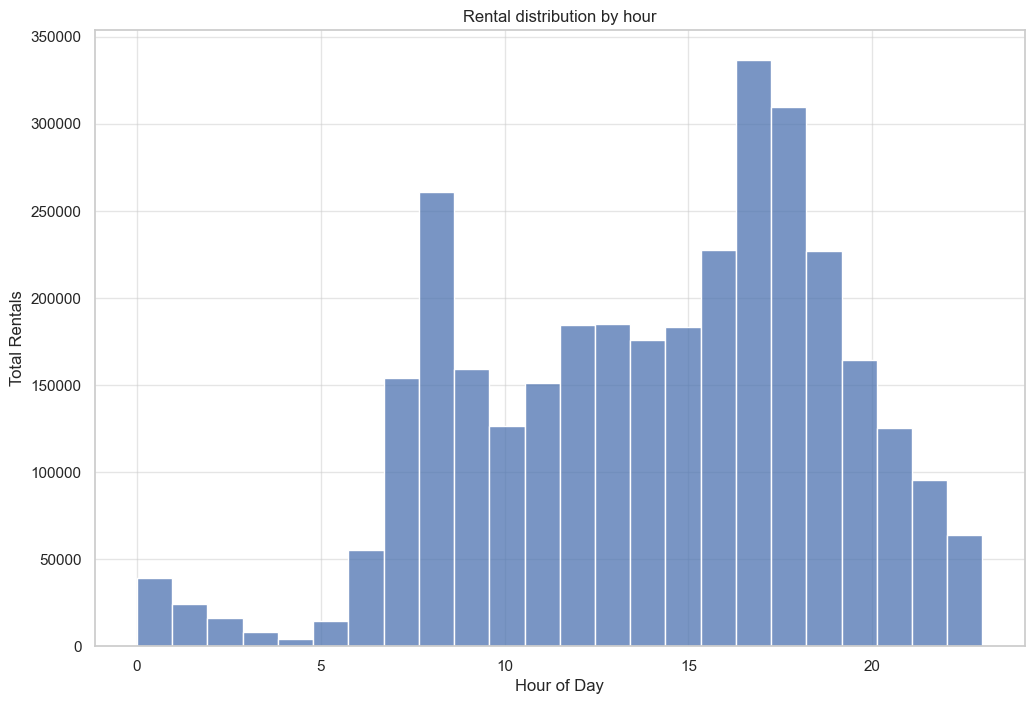

In [16]:
# Histogram: Rental distribution x hour
sns.set(style='whitegrid')

#Distribution of rentals by hour
plt.figure(figsize=(12,8))
sns.histplot(data=df_clean, x='hour', weights='rental_count', bins = 24, kde=False)
plt.title('Rental distribution by hour')
plt.xlabel('Hour of Day')
plt.ylabel('Total Rentals')
plt.show()

In [17]:
df_clean['weather'].value_counts()

weather
Clear              11413
Heavy Rain/Ice      4544
Light Rain/Snow     1419
Misty/Cloudy           3
Name: count, dtype: int64

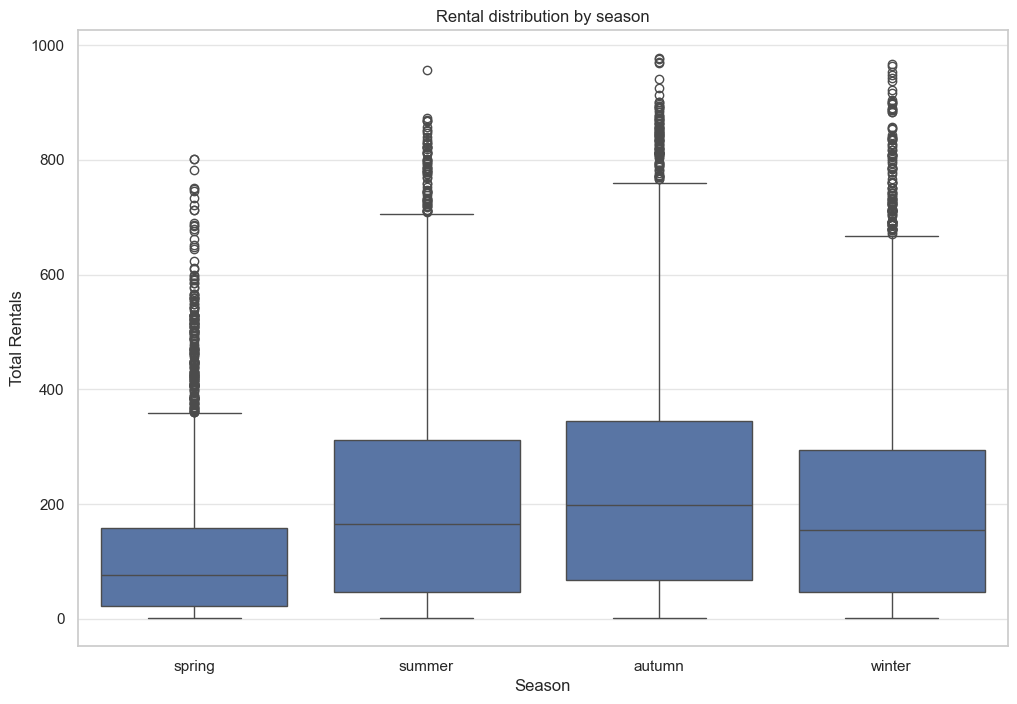

In [18]:
#Boxplot: Rentals x Season
plt.figure(figsize=[12, 8])
sns.boxplot(data=df_clean, x='season', y='rental_count')
plt.title('Rental distribution by season')
plt.xlabel('Season')
plt.ylabel('Total Rentals')
plt.show()

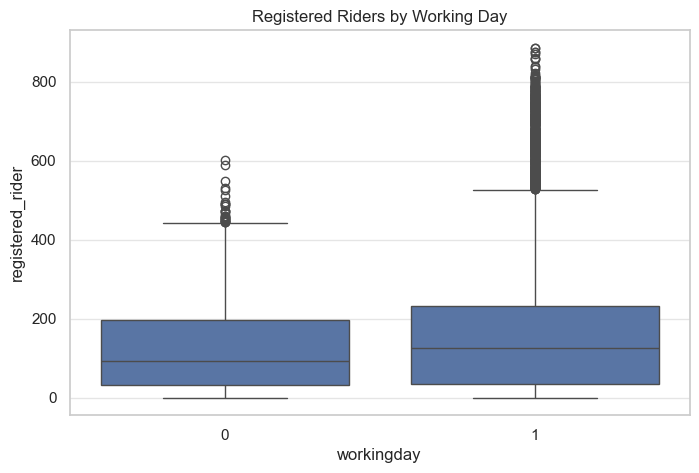

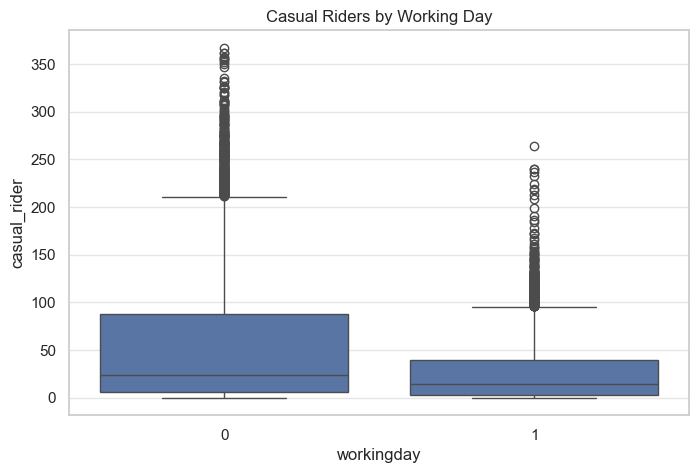

In [19]:
plt.figure(figsize=[8,5])
sns.boxplot(data=df_clean, x='workingday', y='registered_rider')
plt.title('Registered Riders by Working Day')
plt.show()

plt.figure(figsize=[8,5])
sns.boxplot(data=df_clean, x='workingday', y='casual_rider')
plt.title('Casual Riders by Working Day')
plt.show()

<Axes: xlabel='weather', ylabel='rental_count'>

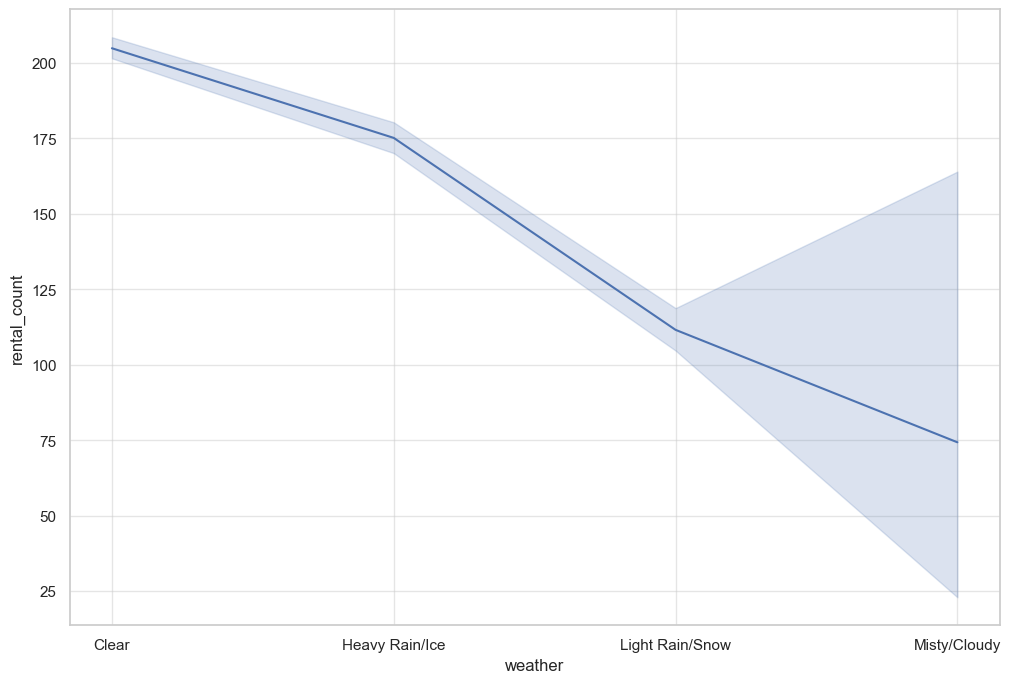

In [20]:
plt.figure(figsize=[12, 8])
sns.lineplot(data=df_clean, x='weather', y='rental_count')

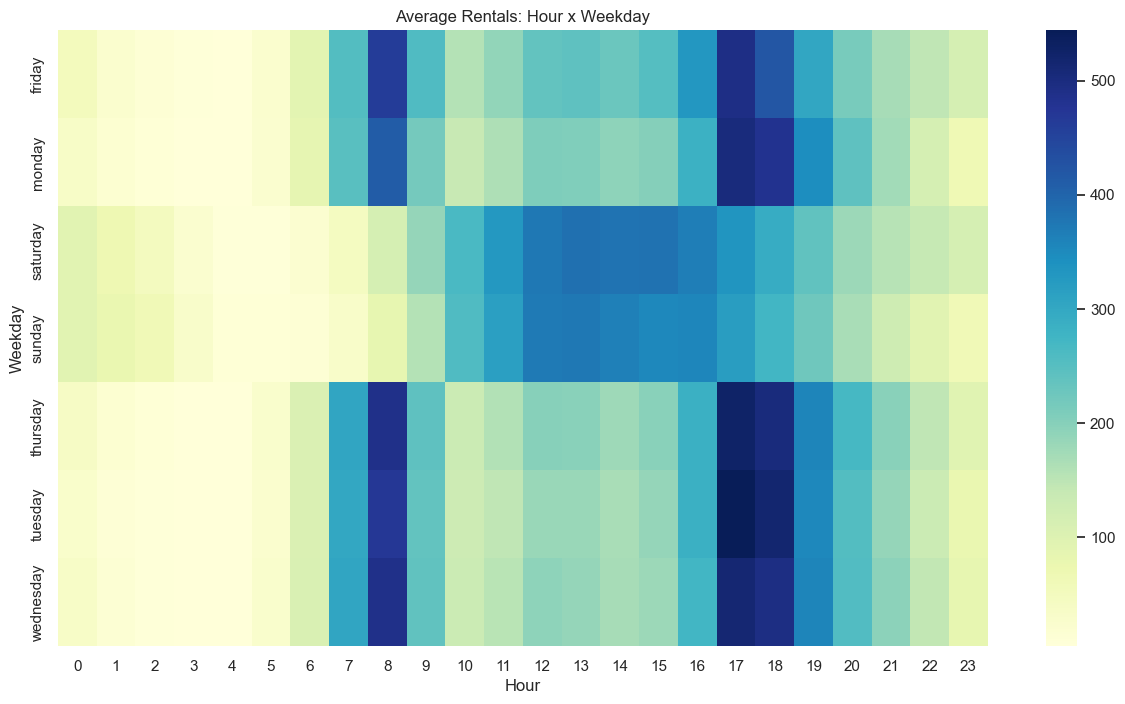

In [21]:
# Hour vs. Weekday heatmap
heat = df_clean.pivot_table(values='rental_count',index='weekday', columns='hour', aggfunc='mean')

plt.figure(figsize=(15,8))
sns.heatmap(heat, cmap='YlGnBu')
plt.title('Average Rentals: Hour x Weekday')
plt.xlabel('Hour')
plt.ylabel('Weekday')
plt.show()


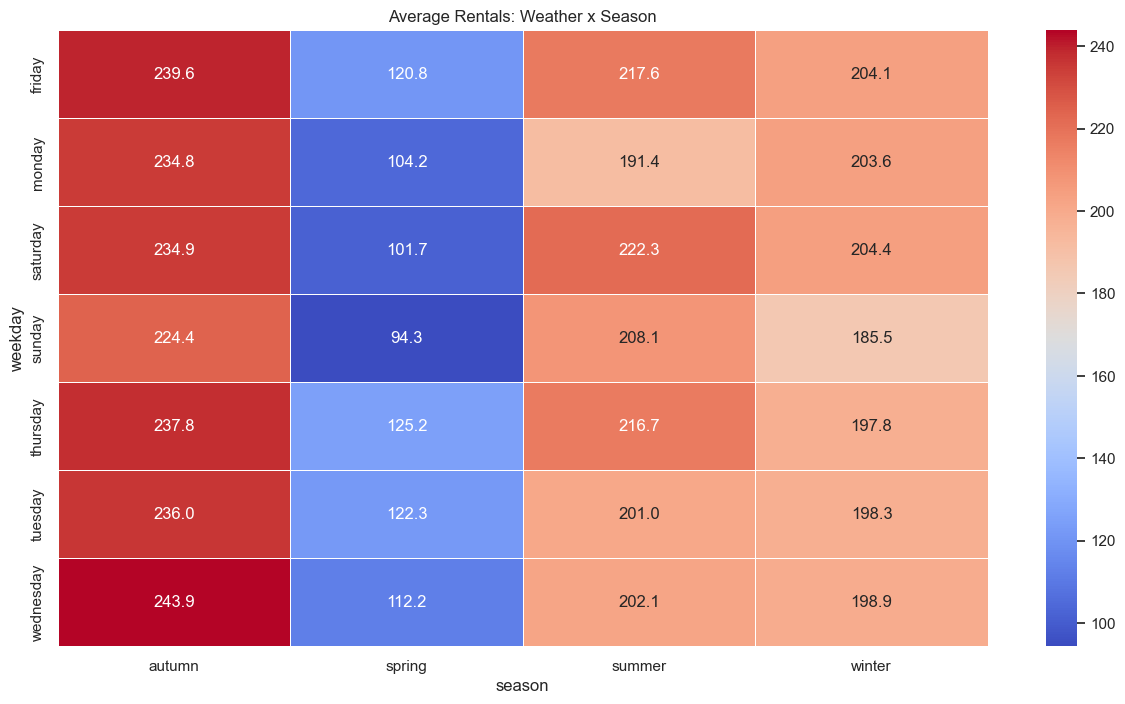

In [22]:
#Weather x Season
weather_season = df_clean.pivot_table(values='rental_count',index='weekday', columns='season', aggfunc='mean')

plt.figure(figsize=(15,8))
sns.heatmap(weather_season, annot=True, cmap='coolwarm', fmt='.1f', linewidths=.5)
plt.title('Average Rentals: Weather x Season')
plt.show()

In [23]:
from scipy.stats import ttest_ind

# Welch T-test to compare casual vs registered population
casual = df_clean['casual_rider']
registered = df_clean['registered_rider']

t_stat, p_val = ttest_ind(casual, registered, equal_var=False)

print('T-test: Casual vs Registered Riders')
print(f'T-Statistic: {t_stat:.4f}')
print(f'p-value: {p_val:.6f}')

T-test: Casual vs Registered Riders
T-Statistic: -97.8133
p-value: 0.000000


In [24]:
pd.crosstab(df_clean['year'], df_clean['weather'])

weather,Clear,Heavy Rain/Ice,Light Rain/Snow,Misty/Cloudy
year,,,,
2011,5645,2218,781,1
2012,5768,2326,638,2


In [25]:
print(df_clean[['casual_rider', 'registered_rider']].describe())

       casual_rider  registered_rider
count  17379.000000      17379.000000
mean      35.676218        153.786869
std       49.305030        151.357286
min        0.000000          0.000000
25%        4.000000         34.000000
50%       17.000000        115.000000
75%       48.000000        220.000000
max      367.000000        886.000000


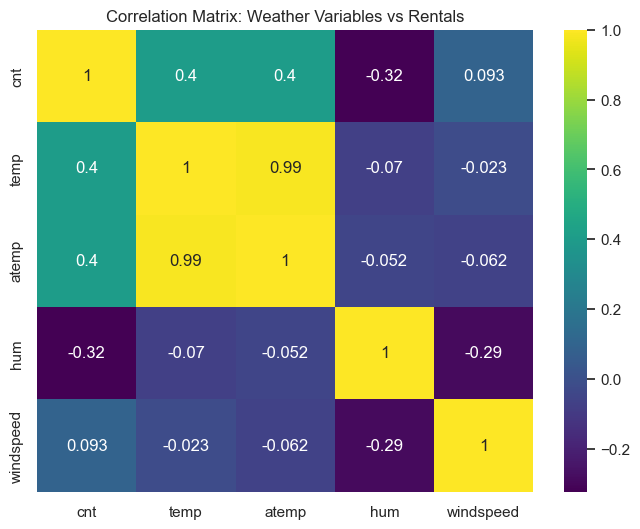

For every increase in normalized temperature, rentals have a 0.40 correlation coefficient.


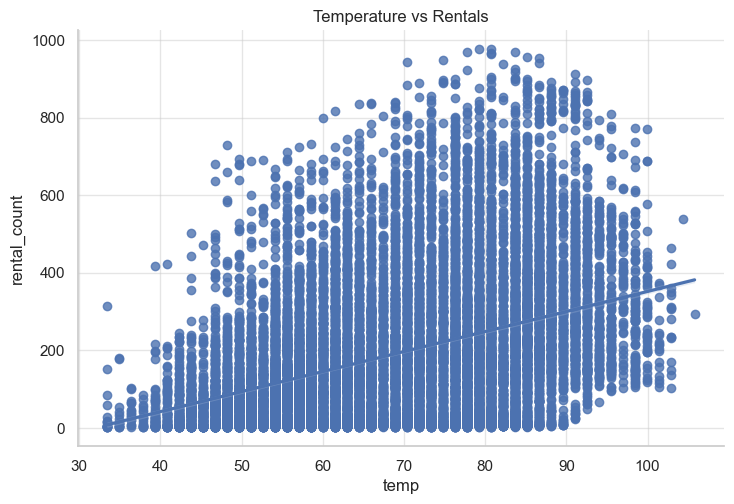

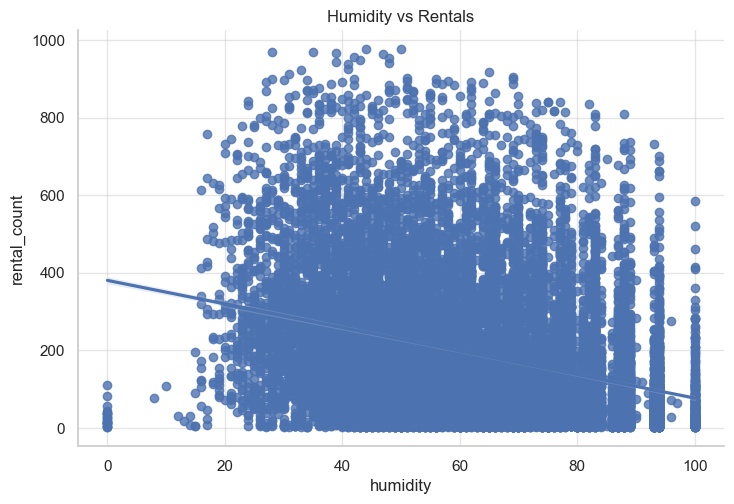

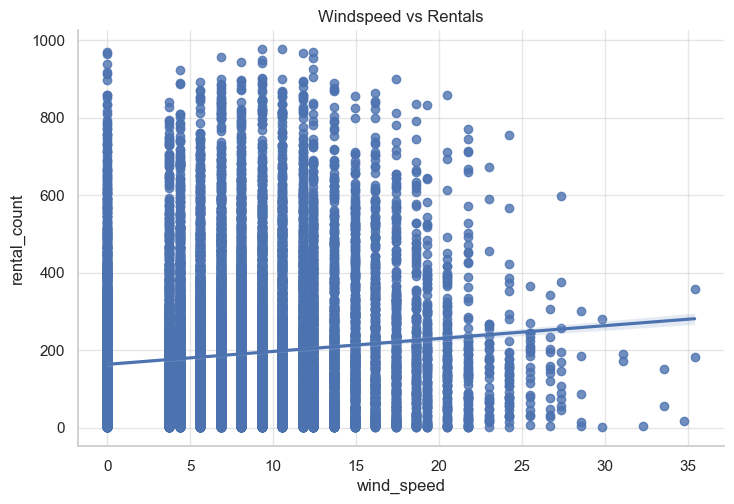

In [26]:
#Correlation Analysis: Weather, Temp, Humidity, WindSpeed

# Select numeric variables
corr_vars = ["cnt", "temp", "atemp", "hum", "windspeed"]

corr_matrix = df[corr_vars].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="viridis")
plt.title("Correlation Matrix: Weather Variables vs Rentals")
plt.show()

# Insight extraction
temp_corr = corr_matrix.loc['cnt', 'temp']
print(f"For every increase in normalized temperature, rentals have a {temp_corr:.2f} correlation coefficient.")

# Scatterplots with regression lines
sns.lmplot(data=df_clean, x="temp", y="rental_count", height=5, aspect=1.5)
plt.title("Temperature vs Rentals")
plt.show()

sns.lmplot(data=df_clean, x='humidity', y="rental_count", height=5, aspect=1.5)
plt.title("Humidity vs Rentals")
plt.show()

sns.lmplot(data=df_clean, x="wind_speed", y="rental_count", height=5, aspect=1.5)
plt.title("Windspeed vs Rentals")
plt.show()


In [27]:
df_clean.items()

<generator object DataFrame.items at 0x0000013B56605F30>

In [28]:
# import statsmodels.api as sm
# # from statsmodels.formula.api import ols
#
# model = ols("cnt ~ C(season)", data=df).fit()
# anova_table = sm.stats.anova_lm(model, typ=2)
#
# print(anova_table)


In [29]:
# import statsmodels.api as sm
#
# X = df[["temp", "hum", "windspeed"]]
# y = df["cnt"]
#
# X = sm.add_constant(X)
# model = sm.OLS(y, X).fit()
#
# print(model.summary())
